In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms

def seed_everything(seed=42):
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [2]:
import os, glob, tarfile

src = '/kaggle/input/datasets/amirsafarzadeh8203/cifar-10-python-tar-gz'

found = glob.glob(src + '/**/cifar-10-batches-py', recursive=True)
if found:
    root = os.path.dirname(found[0])
else:
    tar_path = glob.glob(src + '/**/*.tar*', recursive=True)[0]
    os.makedirs('/kaggle/working/data', exist_ok=True)
    with tarfile.open(tar_path) as tar:
        tar.extractall('/kaggle/working/data')
    root = '/kaggle/working/data'

print(root)
print(os.listdir(os.path.join(root, 'cifar-10-batches-py')))

/kaggle/input/datasets/amirsafarzadeh8203/cifar-10-python-tar-gz
['data_batch_1', 'data_batch_2', 'batches.meta', 'test_batch', 'data_batch_3', 'data_batch_5', 'data_batch_4', 'readme.html']


In [3]:
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed_everything(42)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(224, padding=28),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_full = datasets.CIFAR10(root, train=True, download=False, transform=train_transform)
val_full   = datasets.CIFAR10(root, train=True, download=False, transform=test_transform)
test_dataset = datasets.CIFAR10(root, train=False, download=False, transform=test_transform)

train_idx, val_idx = train_test_split(range(len(train_full)), test_size=0.1, random_state=42,
                                      stratify=train_full.targets)

train_subset = Subset(train_full, train_idx)  # with augmentation
val_subset   = Subset(val_full, val_idx)      # without augmentation

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)

val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)


print(f"Train size: {len(train_subset)}, Val size: {len(val_subset)}, Test size: {len(test_dataset)}")
print(f"train classes: {train_full.classes}")

Train size: 45000, Val size: 5000, Test size: 10000
train classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
def build_model(dropout_p=0.3):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True

    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(model.fc.in_features, 10),
    )
    return model.to(device)

In [5]:
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    model.train()

    test_acc = correct / total

    return test_acc

def evaluate_per_class_acc(model, loader, device, classes):
    model.eval()

    class_correct = torch.zeros(len(classes))
    class_total = torch.zeros(len(classes))

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            for c in range(len(classes)):
                mask = (labels == c)
                class_total[c] += mask.sum().item()
                class_correct[c] += (preds[mask] == c).sum().item()

    model.train()

    per_class_acc = class_correct / class_total.clamp(min=1)

    return per_class_acc

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(loader)

def check_early_stop(val_loss, best_loss, counter, patience=5):
    if val_loss < best_loss:
        return val_loss, 0, False       
    else:
        counter += 1
        return best_loss, counter, counter >= patience   

In [6]:
seed_everything(42)

model = build_model(dropout_p=0.4899448573056766)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 8.957680031001757e-05},
    {'params': model.fc.parameters(), 'lr': 0.00010007378780798995,},
], weight_decay=6.819429058550563e-05)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)
scaler = torch.amp.GradScaler(device)

best_val_loss = float('inf')
counter = 0

train_losses = []
val_losses = []
val_accs = []


for epoch in range(1, 16):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device.type, dtype=torch.float16):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    val_loss = evaluate_loss(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    val_acc = evaluate(model, val_loader, device)

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    layer4_lr = optimizer.param_groups[0]['lr']
    fc_lr = optimizer.param_groups[1]['lr']

    print(f"Epoch {epoch}: layer4 lr={layer4_lr:.6f}, fc lr={fc_lr:.6f}, "
          f"train_loss={avg_train_loss:.4f}, val_loss={val_loss:.4f}, "
          f"val_acc={val_acc*100:.2f}%"
          f"{', checkpoint saved!!!' if val_loss < best_val_loss else ', checkpoint not saved'}")
    
    if val_loss < best_val_loss:
        torch.save(model.state_dict(), 'best_reg_cnn_model_finetuned_final_v2.pth')

    best_val_loss, counter, should_stop = check_early_stop(val_loss, best_val_loss, counter, patience=3)

    if should_stop:
        print(f"Early stopping in epoch {epoch}")
        break


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s]


Epoch 1: layer4 lr=0.000090, fc lr=0.000100, train_loss=0.5590, val_loss=0.2905, val_acc=89.74%, checkpoint saved!!!
Epoch 2: layer4 lr=0.000090, fc lr=0.000100, train_loss=0.3015, val_loss=0.2314, val_acc=92.44%, checkpoint saved!!!
Epoch 3: layer4 lr=0.000090, fc lr=0.000100, train_loss=0.2373, val_loss=0.2194, val_acc=92.94%, checkpoint saved!!!
Epoch 4: layer4 lr=0.000090, fc lr=0.000100, train_loss=0.1948, val_loss=0.2169, val_acc=93.30%, checkpoint saved!!!
Epoch 5: layer4 lr=0.000090, fc lr=0.000100, train_loss=0.1649, val_loss=0.2073, val_acc=93.18%, checkpoint saved!!!
Epoch 6: layer4 lr=0.000090, fc lr=0.000100, train_loss=0.1418, val_loss=0.2227, val_acc=92.74%, checkpoint not saved
Epoch 7: layer4 lr=0.000090, fc lr=0.000100, train_loss=0.1227, val_loss=0.1964, val_acc=93.48%, checkpoint saved!!!
Epoch 8: layer4 lr=0.000090, fc lr=0.000100, train_loss=0.1065, val_loss=0.2054, val_acc=93.56%, checkpoint not saved
Epoch 9: layer4 lr=0.000045, fc lr=0.000050, train_loss=0.0896

In [7]:
model.load_state_dict(torch.load('best_reg_cnn_model_finetuned_final_v2.pth'))
final_test_acc = evaluate(model, test_loader, device)
final_per_class_acc = evaluate_per_class_acc(model, test_loader, device, train_full.classes)
print(f"Final test accuracy (best checkpoint): {final_test_acc*100:.2f}%")

print("\nAccuracy per class:")
for i, c in enumerate(train_full.classes):
    print(f"  {c}: {final_per_class_acc[i].item()*100:.2f}%")

worst_acc = final_per_class_acc.min().item()
worst_classes = [c for i, c in enumerate(train_full.classes) if abs(final_per_class_acc[i].item() - worst_acc) < 1e-9]
print(f"\nWorst class/classes: {worst_classes} with accuracy = {worst_acc*100:.2f}%")

Final test accuracy (best checkpoint): 93.10%

Accuracy per class:
  airplane: 97.70%
  automobile: 97.50%
  bird: 91.30%
  cat: 83.70%
  deer: 91.10%
  dog: 87.80%
  frog: 96.90%
  horse: 95.70%
  ship: 95.10%
  truck: 94.20%

Worst class/classes: ['cat'] with accuracy = 83.70%


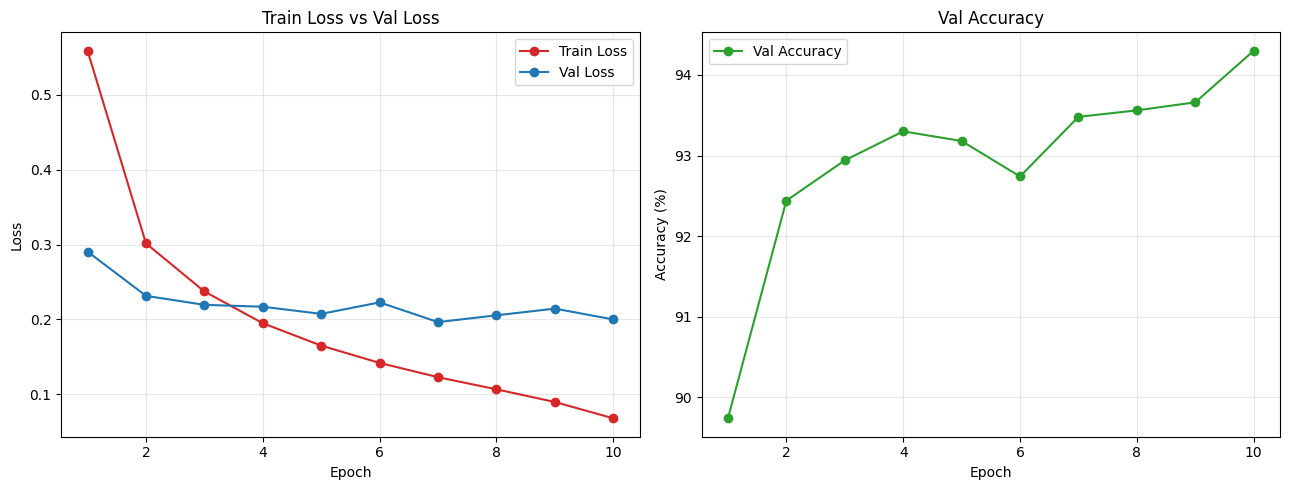

In [8]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_losses) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
plt.subplots_adjust(wspace=0.35)

# train loss and val loss 
ax1.plot(epochs, train_losses, color='tab:red', marker='o', label='Train Loss')
ax1.plot(epochs, val_losses, color='tab:blue', marker='o', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Train Loss vs Val Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# val accuracy
ax2.plot(epochs, [a * 100 for a in val_accs], color='tab:green', marker='o', label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Val Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_full.classes))

cm = confusion_matrix(all_labels, all_preds)

              precision    recall  f1-score   support

    airplane       0.90      0.98      0.94      1000
  automobile       0.95      0.97      0.96      1000
        bird       0.93      0.91      0.92      1000
         cat       0.88      0.84      0.86      1000
        deer       0.94      0.91      0.93      1000
         dog       0.88      0.88      0.88      1000
        frog       0.94      0.97      0.95      1000
       horse       0.93      0.96      0.94      1000
        ship       0.97      0.95      0.96      1000
       truck       0.98      0.94      0.96      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



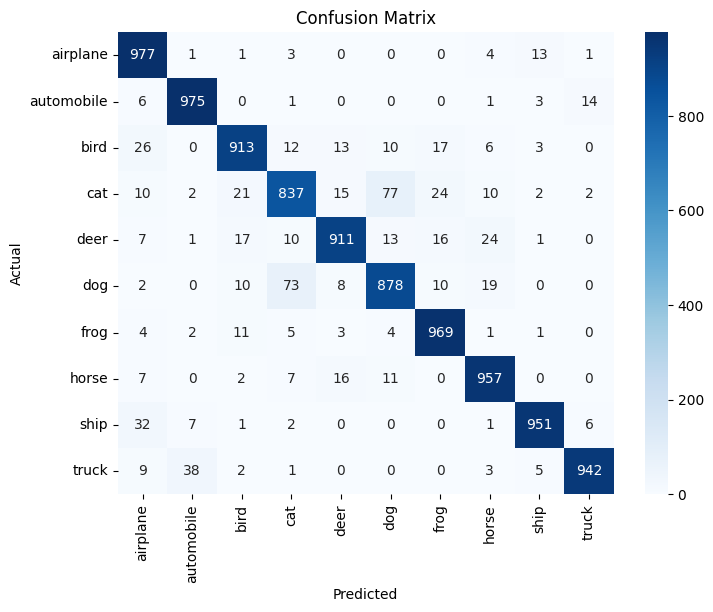

In [10]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_full.classes, yticklabels=train_full.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()